In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from numpy.random import Generator, MT19937

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score 
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from pathlib import Path

### Load and preprocess data

In [23]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.
scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna(how="all").sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
	scaler.fit_transform(numeric_attributes.values),
	columns=numeric_attributes.columns,
	index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
	scaler.fit_transform(numeric_hy_id.values),
	columns=numeric_hy_id.columns,
	index=numeric_hy_id.index
)

print(f"attributes shape: {numeric_attributes.shape}")
print(f"hy id shape: {numeric_hy_id.shape}")

attributes shape: (859, 60)
hy id shape: (842, 14)


### Pick attributes

We got 29 attributes.


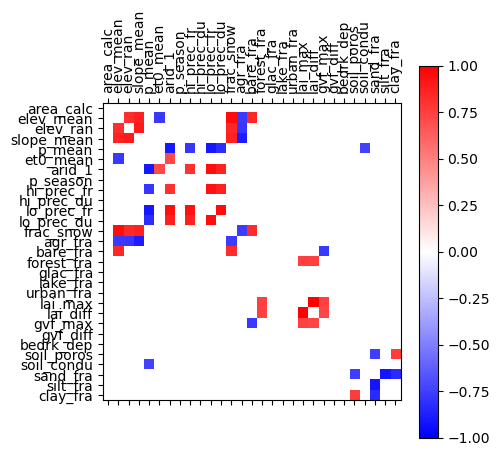

In [24]:
potential_attributes = [
	#geomorph - unargueable
	"area_calc", # how much water is available *
	"elev_mean", # how much snow, how much energy *
	"elev_ran", # how variable is the catchment
	"slope_mean", # energy of surface runoff *(since mountains)

	#precipitation
	"p_mean", # influx *
	"et0_mean", # outflux *
	"arid_1", # there are some arid catchments (more et0 than p_mean)
	"p_season", # encode seasonal pattern *
	"hi_prec_fr", # how often do high prec events occur (days/yr with p > 5*p_mean) *
	"hi_prec_du", #*
	"lo_prec_fr", # how often do low prec events occur (days/yr with p < 1 mm/d) *
	"lo_prec_du", #*
	"frac_snow", # essential in mountainous catchments *

    #land cover - nice, since they are accurate over the catchment, and not averaged
	"agr_fra", # 
	"bare_fra", # 
	"forest_fra", # storage
	"glac_fra", # super rare case, and then not that important 
	"lake_fra", # storage, also quite rare
	"urban_fra", # * versieglung, an proxy for disturbance of natural waterways

	#vegetation - represent water storage, and also differences between summer and winter - choose lai or ndvi, since they are correlated. And lai also has some info, about how many layers of vegetation there are. 
	"lai_max", 
	"lai_diff",
	"gvf_max",
	"gvf_diff",

	#soil - represent storage and also percolation speed
	"bedrk_dep", #*
	"soil_poros", #*
	"soil_condu", #*
	"sand_fra", #*
	"silt_fra", #*
	"clay_fra" #*
	]

len(potential_attributes)

picked_attributes = scaled_attributes[potential_attributes]

corr_mat = picked_attributes.corr()

for i in range(len(corr_mat)): 

	corr_mat.iloc[i,i] = np.nan

plt.matshow(corr_mat[corr_mat.abs() > 0.7 ], cmap="bwr", vmin=-1, vmax=1)
plt.yticks(ticks=range(len(corr_mat)), labels=corr_mat.columns)
plt.xticks(ticks=range(len(corr_mat)), labels=corr_mat.columns, rotation=90)
plt.colorbar()
print(f"We got {len(picked_attributes.columns)} attributes.")

### Determine strata

In [25]:
# PCA since there are a lot of attributes, which are sometimes correlated. 
pca = PCA(n_components=0.9, svd_solver="full")
pca_attributes = pca.fit_transform(picked_attributes)


In [26]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:10<00:00,  9.34it/s]


Text(0.5, 1.0, 'CH_scores')

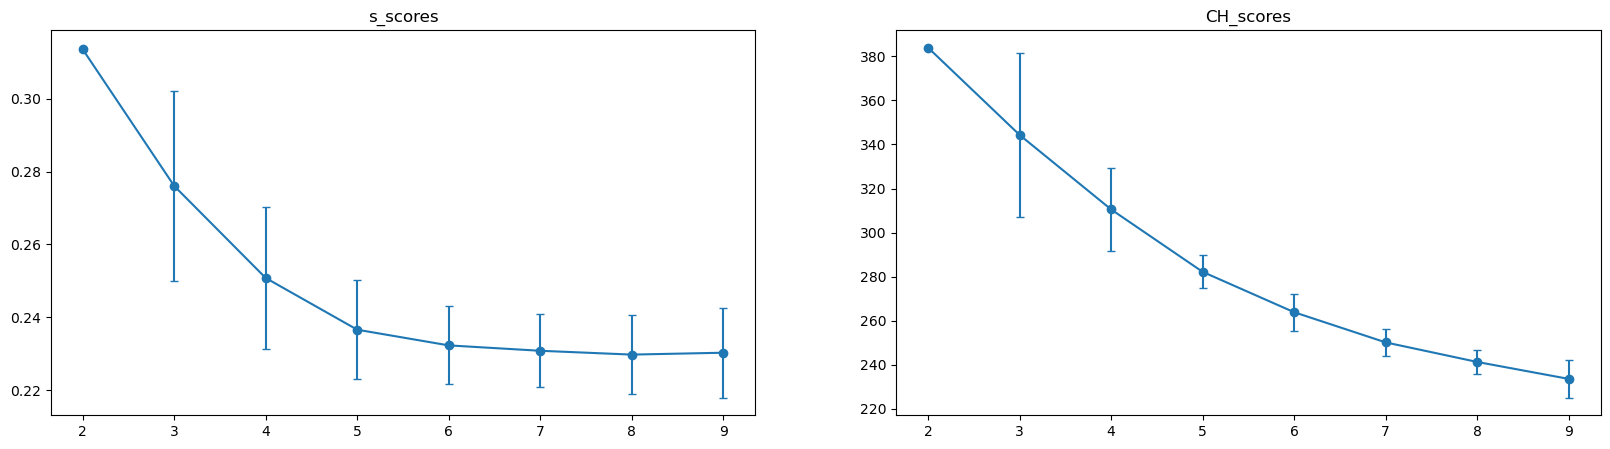

In [27]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 
CH_scores =  np.zeros([n_seeds,10])

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(pca_attributes)
		s_scores[i,k] = silhouette_score(pca_attributes,labels) # higher is better
		CH_scores[i,k] = calinski_harabasz_score(pca_attributes,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]
avg_ch_scores = CH_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]
std_ch_scores = CH_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,2, figsize=(20,5))

axs[0].errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)
axs[1].errorbar(range(2,10), avg_ch_scores, yerr=std_ch_scores, marker="o", capsize=3)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")

In [28]:
from collections import Counter 

c = Counter(s_scores[:,3])
print(c)

Counter({0.28446383355366595: 57, 0.2862913870754156: 18, 0.21332791654403754: 14, 0.28600480016386637: 3, 0.2860880661330698: 2, 0.28582269731286536: 2, 0.32116371422154766: 2, 0.2855274878678285: 1, 0.3218018016110568: 1})


In [41]:
picked_attributes

,area_calc,elev_mean,elev_ran,slope_mean,p_mean,et0_mean,arid_1,p_season,hi_prec_fr,hi_prec_du,...,lai_max,lai_diff,gvf_max,gvf_diff,bedrk_dep,soil_poros,soil_condu,sand_fra,silt_fra,clay_fra
ID,,,,,,,,,,,,,,,,,,,,,
1,0.935373,0.603581,2.471568,1.123893,1.561496,0.510470,-0.930091,-0.281731,-0.745283,-0.200899,...,-0.245938,-0.071325,0.247664,0.994711,-0.235364,-0.975931,-0.863772,1.774473,-1.572511,-1.581440
2,-0.358738,1.433074,1.537878,1.396980,1.521445,-0.359749,-1.075632,-1.035981,-1.049811,1.207854,...,-0.869949,-0.702707,0.084078,2.087366,-0.591208,-0.975931,-0.998336,0.958303,-0.637763,-1.114369
3,0.903669,1.579857,2.284551,1.412585,1.271127,-0.504786,-1.002862,-0.928231,-0.905561,1.207854,...,-0.959093,-0.763417,-0.324886,1.795991,-0.585857,-0.634455,-0.946247,0.424266,-0.224023,-0.604836
4,-0.495743,1.636181,1.183384,1.592042,1.531458,-0.988241,-1.148403,-0.928231,-1.226117,1.677438,...,-0.925664,-0.702707,-0.079508,2.451584,-0.591208,0.048498,-1.002677,-0.603503,1.001876,-0.116533
5,-0.472293,1.431368,1.871438,1.896339,1.661623,-0.263058,-1.112018,-0.928231,-0.665144,0.973062,...,-1.159668,-0.994114,-1.224607,0.921867,-0.605924,0.048498,-0.993995,-0.684112,0.971229,0.095772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878,0.697026,-0.852299,-0.794251,-0.990579,-1.562475,0.752198,2.089889,0.149270,1.354358,0.973062,...,-0.569087,-0.605571,-0.243093,-0.389319,-0.526996,-0.292978,1.002757,0.252972,-0.484526,0.138233
879,1.407331,-0.842059,-0.706325,-1.123221,-1.562475,0.848889,2.126274,0.364770,1.258191,0.738270,...,-0.580230,-0.654139,-0.324886,-0.462163,-0.477499,0.389975,0.503569,-0.512817,0.281661,0.690227
880,-0.355770,-1.072474,-0.970103,-0.896949,-1.672615,1.719108,2.817595,0.364770,1.466552,2.147023,...,-0.245938,-0.253454,-0.161300,-0.607850,-0.498903,0.389975,1.185070,-0.422132,0.113100,0.732688


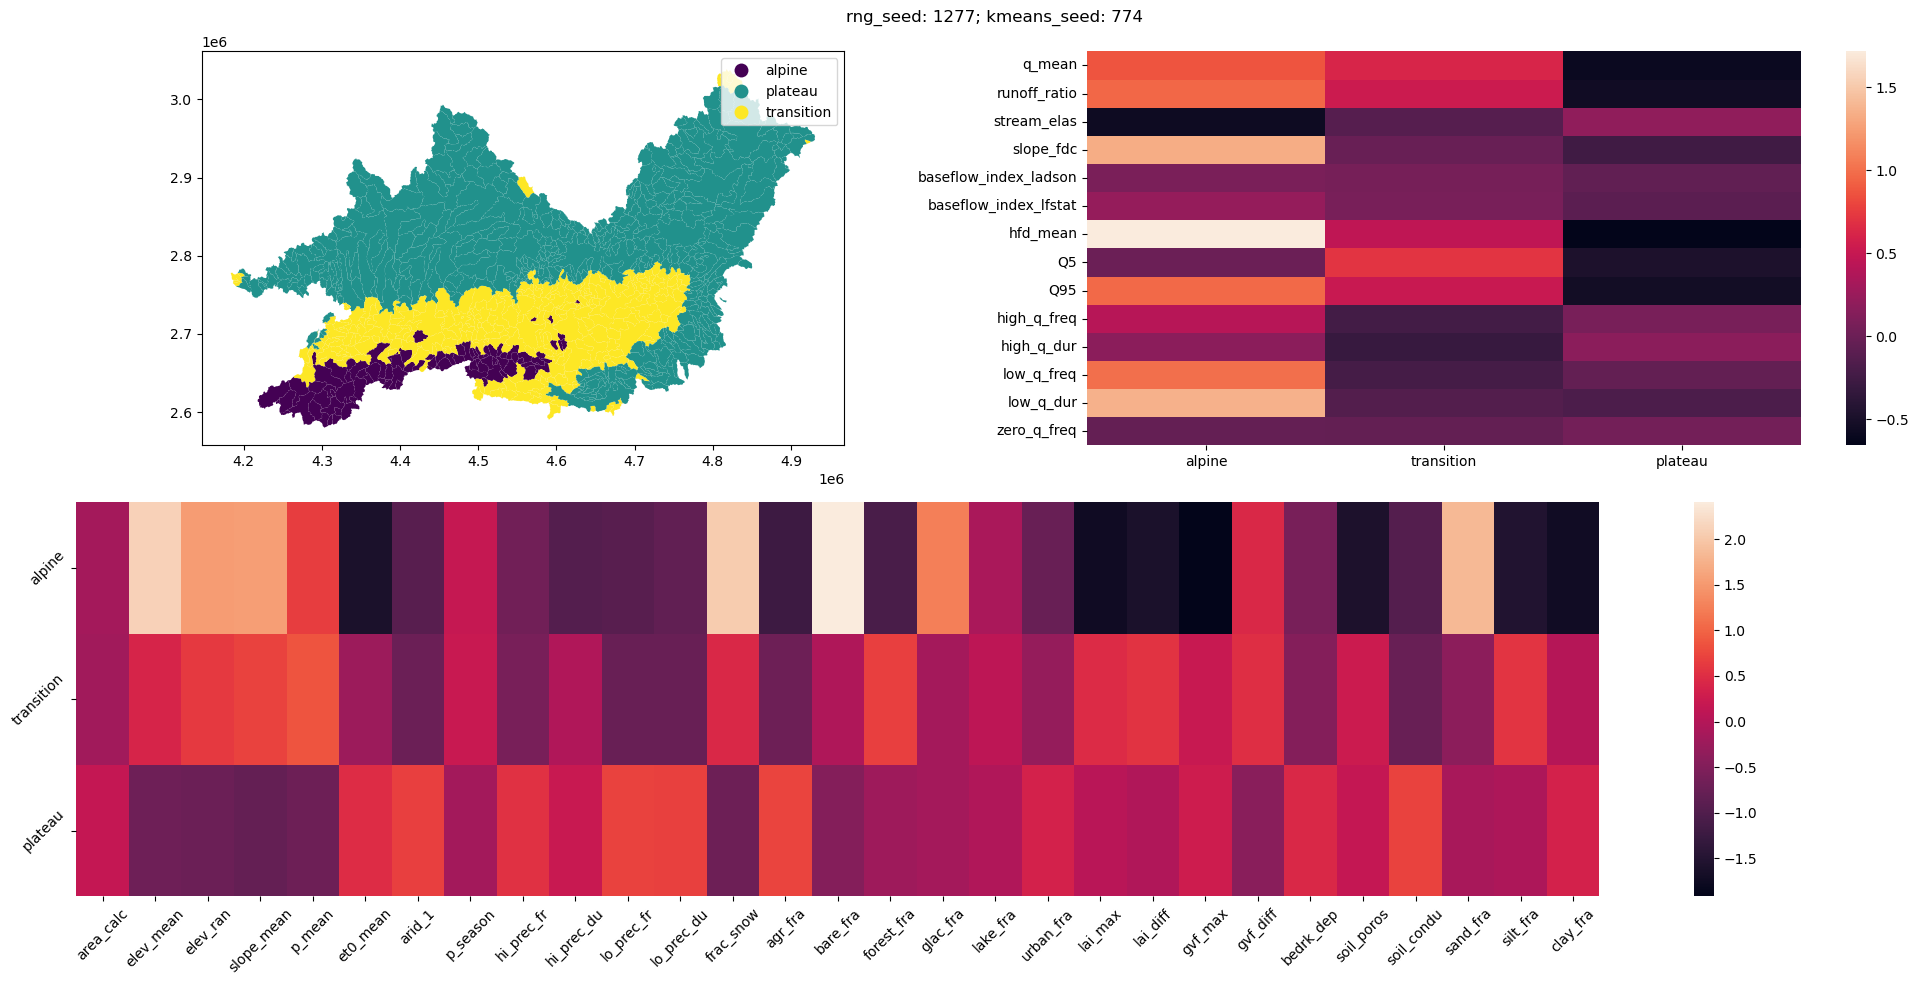

In [ ]:
n_clusters = 3
kmeans_seed = seeds[np.where(s_scores[:,3] == c.most_common(1)[0][0])[0][0]]

# KMEANS
kmeans = KMeans(n_clusters=n_clusters, random_state=kmeans_seed)

kmeans_labels = pd.Series(kmeans.fit_predict(pca_attributes), scaled_attributes.index)

# rearrange ids for better displaying
def remap_ids(org_id:int): 

	id_mapping = {
		"0": 1,
		"1": 0,
		"2": 2
	}

	return id_mapping[str(org_id)]

kmeans_labels = kmeans_labels.apply(remap_ids)

def remap_labels(org_label:int): 

	mapping = {
		"0": "alpine",
		"1": "transition",
		"2": "plateau",
	}

	return mapping[str(org_label)]

kmeans_str_labels = kmeans_labels.apply(remap_labels)

# PLOT
plot_gdf = no_na_attributes.copy()
plot_gdf["kmeans_labels"] = kmeans_str_labels

fig, axs = plt.subplot_mosaic("AB;CC", figsize=(20,10))

plot_gdf.plot(
	column="kmeans_labels",
	cmap="viridis",
	ax= axs["A"],
	legend=True,)

strata_label_list = ["alpine", "transition", "plateau"]

# Plot hy id and attributes in the strata.
sns.heatmap(ax=axs["B"], data = scaled_hy_id.groupby(kmeans_labels).mean().transpose(), xticklabels=strata_label_list)
sns.heatmap(ax=axs["C"], data = picked_attributes.groupby(kmeans_labels).mean(), yticklabels=strata_label_list)
axs["C"].tick_params("both", rotation=45)

fig.suptitle(f"rng_seed: {rng_seed}; kmeans_seed: {kmeans_seed}")

plt.tight_layout()

In [30]:
sampling_seed = 1277 

train_ids = []
val_ids = []
test_ids = []

for strata in kmeans_labels.unique(): 

	# Randomly sample 80% of strata for training.
	strata_train_ids, strata_rest_ids = train_test_split(kmeans_labels[kmeans_labels == strata], train_size=0.8, random_state=seed)

	# Split the remaining 20% into validation and test. 
	strata_val_ids, strata_test_ids = train_test_split(strata_rest_ids, train_size=0.5, random_state=seed)

	train_ids.extend(strata_train_ids.index.to_list())
	val_ids.extend(strata_val_ids.index.to_list())
	test_ids.extend(strata_test_ids.index.to_list())

train_ids.sort()
val_ids.sort()
test_ids.sort()

In [31]:
len(test_ids)

87

<Axes: >

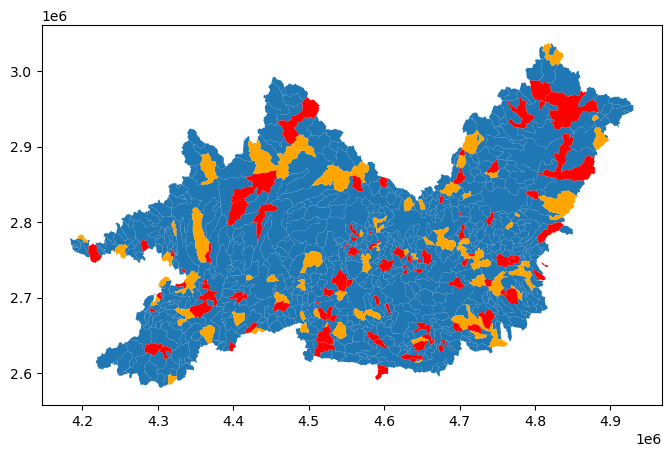

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_gdf.loc[train_ids].plot(ax=ax)
plot_gdf.loc[val_ids].plot(ax=ax, color="orange")
plot_gdf.loc[test_ids].plot(ax=ax, color="red")

### Save strata and sets

In [33]:
if "urban_fra" in potential_attributes: 

	splits_directory_path = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover")

else: 

	splits_directory_path = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_excl_landcover")

In [55]:
kmeans_labels_df = pd.DataFrame(kmeans_labels)
kmeans_labels_df.loc[:,"names"] = kmeans_str_labels

In [58]:
#export Strata
kmeans_labels_df.to_csv(splits_directory_path / "strata_ids.txt")

with open(splits_directory_path / "strata_metadata.txt", "w") as f: 
	f.write(f"rng_seed: {rng_seed}\nkmeans_seed: {kmeans_seed}\nsampling_seed: {sampling_seed}\n{potential_attributes} ")

In [403]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
	for id in train_ids:
		f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
	for id in val_ids:
		f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
	for id in test_ids:
		f.write(f"{id}\n")